# Week 4 - Probability Distributions 3 and Mixture Models

Learning contents:

1. Histogram-based density estimation
    - Display histogram densities
2. Kernel density estimation
    - Hypercube Kernel function
    - Gaussian Kernel function
3. K-Nearest Neigbours classification
    - Generate data
    - Classification function
    - Display results
4. K-Means clustering
    - Display results

## Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from collections import Counter
from scipy.stats import norm
from sklearn import datasets
from math import floor

import seaborn as sns; sns.set_theme(); sns.set_palette('bright')

## Generate data

The provided function `generate_data_1D` below returns `size` samples of a single random variable following a mixture of Gaussians distribution with parameters `means`, `stds` (standard deviations) and `pi` (mixture weights). Read the code and make sure you understand how the mixture is sampled.

In [2]:
#np.random.default_rng(1)
np.random.seed(1)
def generate_data_1D(size, means, stds, pi):
    """Generate 1D samples from a Gaussian mixture model.

    Parameters
    ----------
    size : int
        Number of samples to generate.
    means : list of float
        Component means (mu_k).
    stds : list of float
        Component standard deviations (sigma_k). Note: these are std devs, NOT variances.
    pi : list of float
        Mixture weights (must sum to 1).

    Returns
    -------
    list of float
        Sampled data points.

    Note
    ----
    Call np.random.seed(...) before this function for reproducible results.
    """
    x = []
    for i in range(size):
        z_i = np.argmax(np.random.multinomial(1, pi))
        x_i = np.random.normal(means[z_i], stds[z_i])
        x.append(x_i)
    return x

The function below generates 1000 data points from the Gaussian mixture distribution and plots their histogram. Observe the plot and comment on whether the plot coincides with the input data.

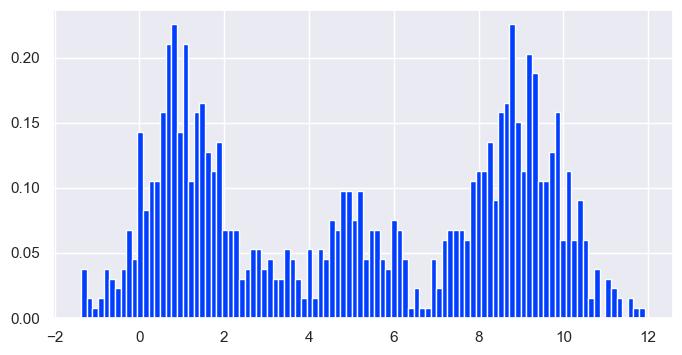

In [3]:
means = [1, 5, 9]
stds = [1, 1, 1]  # standard deviations (sigma_k), not variances
pis = [0.4, 0.2, 0.4]
np.random.seed(10)
data = generate_data_1D(1000, means, stds, pis);
fig, ax = plt.subplots(figsize=(8, 4));
ax.hist(data, bins=100, density=True);

#### Answer

Yes, we can see that the plots match the data: the values of the means are around 1, 5 and 9. The plots show a higher density over these points, suggesting that the random experiments are accurate

## 1) Histogram-based density estimation

write a function `histogram` that takes input `data`, user-defined bin size `delta` and returns `bins` (list of edges of the bins) and their corresponding `probabilities`. Hint: you can use numpy's histogram function to do so.

In [4]:
def histogram(data, delta):
    """Compute a histogram density estimate.

    Parameters
    ----------
    data : list or array of float
        The 1D data samples.
    delta : float
        Bin width (Delta in L7 slide 9).

    Returns
    -------
    bins : numpy array, shape (n_bins + 1,)
        Bin edge positions (left edges plus the rightmost edge).
    probs : numpy array, shape (n_bins,)
        Probability density for each bin (values integrate to ~1 over all bins).

    Hint: use numpy's histogram function with density=True.
    """
    min_x = min(data)
    bins = []
    bins.append(min_x)
    max_x = max(data)
    while bins[-1] < max_x:
        bins.append(bins[-1] + delta)
    
    data_sort = np.sort(data)
    N = len(data_sort) # number of edges

    probabilities = []
    j = 0

    for i in range(len(bins) - 1):
        count = 0
        upper_edge = bins[i + 1]
        last_bin = i == len(bins) - 2

        while j < N:
            x = data_sort[j]

            if x < upper_edge or (last_bin and x <= upper_edge):
                count += 1
                j += 1
            else:
                break

        probabilities.append(count / (N * delta))
    return bins, probabilities
            
    

### 1.1) Display histogram densities

Display the `histograms` for different values of bin sizes and also compute and plot the `true` probability density (slide 9 of lecture 7) of the data. Compare the two plots and see which values of bin sizes reveal densities that are close to the true density function

In [5]:
def univariate_normal(x, mean, variance):
    return ((1. / np.sqrt(2 * np.pi * variance)) * np.exp(-(x - mean)**2 / (2 * variance)))

def display_histogram_density(data, delta):
    bins, probs = histogram(data, delta)

    a = np.arange(-5, 15, 0.01)
    # True mixture density: sum over components of pi_k * N(x | mean_k, std_k^2)
    y = (pis[0] * univariate_normal(a, mean=means[0], variance=stds[0]**2) +
         pis[1] * univariate_normal(a, mean=means[1], variance=stds[1]**2) +
         pis[2] * univariate_normal(a, mean=means[2], variance=stds[2]**2))
    fig, ax = plt.subplots(figsize=(8, 4))
    # Bars must span exactly their bins: anchor each bar at its left edge
    # (align='edge') and use the true bin widths from np.histogram (~delta).
    ax.bar(bins[:-1], probs, width=np.diff(bins), align='edge')
    ax.plot(a, y, '-r')

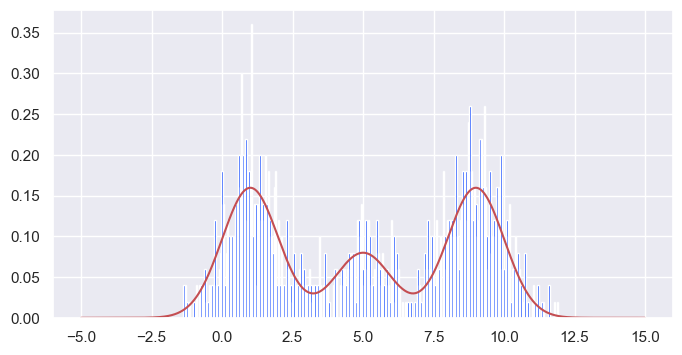

In [6]:
display_histogram_density(data, 0.05)

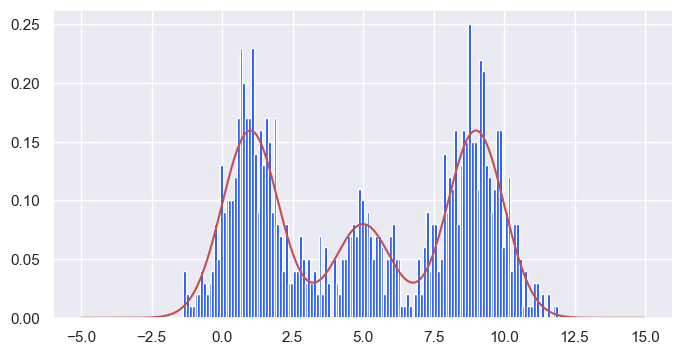

In [7]:
display_histogram_density(data, 0.1)

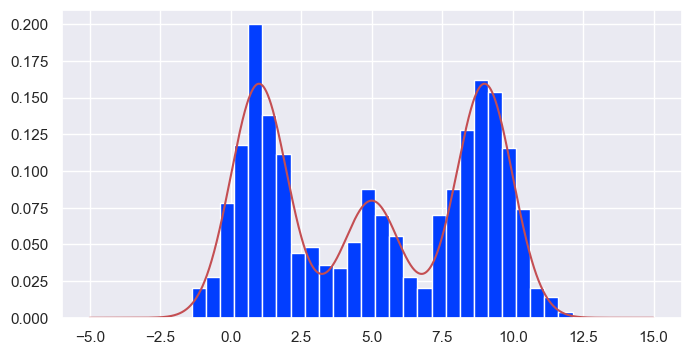

In [8]:
display_histogram_density(data, 0.5)

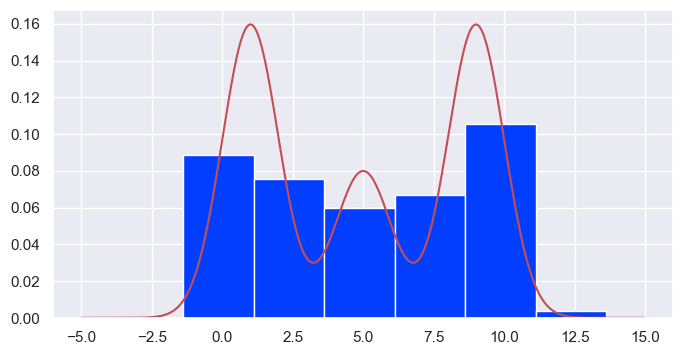

In [9]:
display_histogram_density(data, 2.5)

## 2) Kernel density estimation

### 2.1) Hypercube Kernel function

write a function `hypercube_kernel_function` takes `u` and returns 0 or 1 if `u` is inside 1/2 hypercube (see slide 18 of lecture 7).

In [10]:
def hypercube_kernel_function(u):
    """Hypercube (uniform) kernel function (L7 slide 18).

    Parameters
    ----------
    u : array-like
        Scaled displacement vector (x - x_n) / h; one element per dimension D.

    Returns
    -------
    int
        1 if all |u_i| <= 0.5 (point is inside the unit hypercube), else 0.
    """
    u = np.array(u)
    return int(np.all(np.abs(u) <= 1/2))

write the function `hypercube_kernel_density` that takes a single data point `x`, training data points `data`, size of a cube `h`, data dimensions `D` and returns the probability density of `x` based on the Hypercube kernel function (see the first equation on slide 19 of lecture 7)

In [11]:
def hypercube_kernel_density(x, data, h, D):
    """Hypercube kernel density estimate at point x (L7 slide 19, first equation).

    Parameters
    ----------
    x : array-like
        Query point (scalar for 1D data).
    data : list or array
        Training data points (each element has the same shape as x).
    h : float
        Cube side length (bandwidth).
    D : int
        Number of dimensions (use D=1 for 1D data).

    Returns
    -------
    float
        Probability density estimate at x (>= 0).
    """
    N = len(data)
    kernel_sum = []

    for x_n in data:
        u = (x - x_n) / h
        kernel_value = hypercube_kernel_function(u)
        kernel_sum.append(kernel_value)

    res = sum(kernel_sum) / (N * h**D)
    return res

display the computed nonparametric density estimates for different values of `h`. What is the effect of `h` on density estimates?

In [12]:
def display_hypercube_kernel_density_1D(data, h, color='b'):
    xs = np.linspace(min(data), max(data), 200)
    plt.plot(xs, list(map(lambda x: hypercube_kernel_density(x, data, h, 1), xs)), '-' + color, label='h=' + str(h))
    plt.legend()

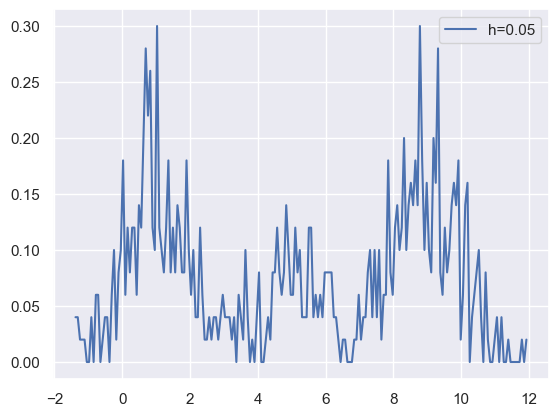

In [13]:
display_hypercube_kernel_density_1D(data, 0.05, 'b')

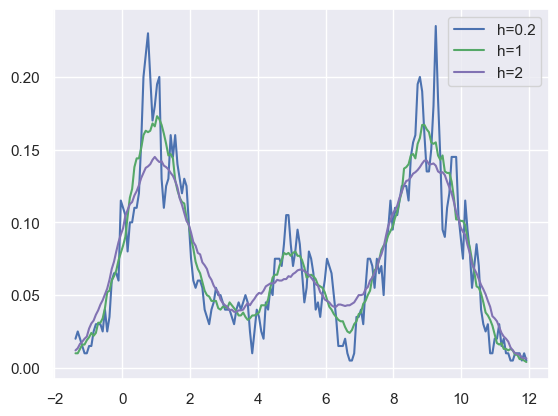

In [14]:
display_hypercube_kernel_density_1D(data, 0.2, 'b')
display_hypercube_kernel_density_1D(data, 1, 'g')
display_hypercube_kernel_density_1D(data, 2, 'm')

### 2.2) Gaussian Kernel function

Write the function `gaussian_kernel_function` that takes pair of points `x` and `x_n`, size `h` and returns Gaussian kernel function value for the pair of points.

In [15]:
def gaussian_kernel_function(x, x_n, h):
    """Gaussian kernel function for a pair of scalar points (L7 slide 19).

    Parameters
    ----------
    x : float
        Query point.
    x_n : float
        Training data point.
    h : float
        Bandwidth (controls the width of the Gaussian).

    Returns
    -------
    float
        Gaussian kernel value >= 0 (equivalent to N(x | x_n, h^2)).
    """
    alpha = 1 / np.sqrt(2 * np.pi * h**2)
    c1 = np.linalg.norm(x - x_n)**2
    c2 = (-1) * 1 / (2 * h**2)
    c3 = np.exp(c1 * c2)
    return alpha * c3

Write the `gaussian_kernel_density` function that takes any point `x`, training data points `data`, size `h` and returns the Gaussian kernel density value for the point `x` (see the last equation in slide 19 of lecture 7)

In [16]:
def gaussian_kernel_density(x, data, h):
    """Gaussian kernel density estimate at point x (L7 slide 19, last equation).

    Parameters
    ----------
    x : float
        Query point.
    data : list or array of float
        Training data points.
    h : float
        Bandwidth.

    Returns
    -------
    float
        Probability density estimate at x (>= 0).
    """
    kernel_values = []

    for x_n in data:
        kernel_value = gaussian_kernel_function(x, x_n, h)
        kernel_values.append(kernel_value)

    return sum(kernel_values) / len(data)

In [17]:
def display_gaussian_kernel_density_1D(data, h, color='b'):
    xs = np.linspace(min(data), max(data), 200)
    plt.plot(xs, list(map(lambda x: gaussian_kernel_density(x, data, h), xs)), '-' + color, label='h=' + str(h))
    plt.legend()

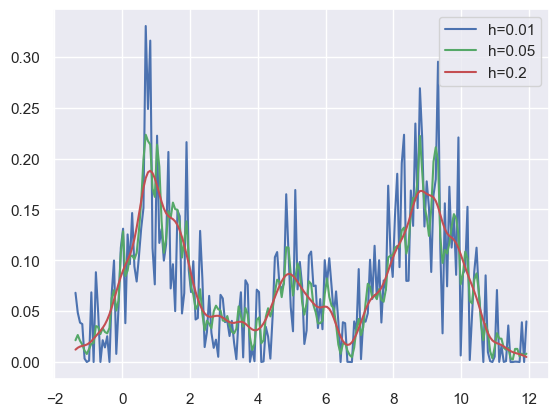

In [18]:
display_gaussian_kernel_density_1D(data, 0.01, 'b')
display_gaussian_kernel_density_1D(data, 0.05, 'g')
display_gaussian_kernel_density_1D(data, 0.2, 'r')

## 3) K-Nearest Neigbours classification

### 3.1) Generate Data

Using IRIS dataset from the sklearn library. Note that the data is 2-dimensional (two features). The data can belong to one of the 3 classes as shown in the following figure with different colors. The following code plots the data and corresponding targets (classes).

(<matplotlib.collections.PathCollection at 0x15aef4290>,
 <matplotlib.legend.Legend at 0x15aea2010>)

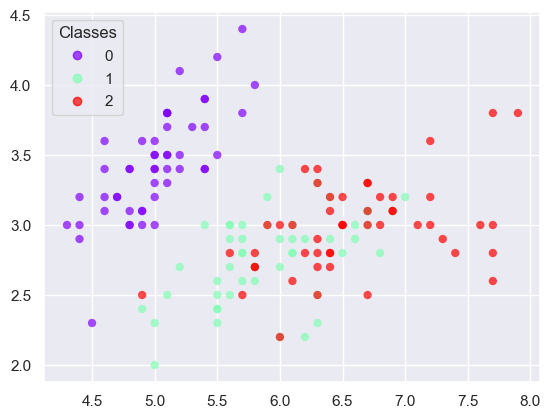

In [19]:
iris = datasets.load_iris()
iris_x = np.array(iris.data[:, :2])  # we only take the first two features.
iris_t = np.array(iris.target)

def plot_iris(legend=True, classes=iris_t, target=plt):
    scatter = target.scatter(iris_x[:, 0], iris_x[:, 1], c=classes, alpha=0.7, cmap='rainbow', edgecolor='none')
    if legend:
        legend = target.legend(*scatter.legend_elements(), loc="upper left", title="Classes")
        return (scatter, legend)
    return (scatter, )

plot_iris()

### 3.2) Classification function

write the `k_nearest_classification` function that takes a test data point `x`, training data points `data_x` and their associated classes `data_t`, the neighbours `k` and returns the predicted class for the test point `x`

In [20]:
def k_nearest_classification(x, data_x, data_t, k):
    """Classify x using the K-nearest neighbours rule.

    Parameters
    ----------
    x : array-like, shape (D,)
        Test data point.
    data_x : array-like, shape (N, D)
        Training data points.
    data_t : array-like, shape (N,)
        Class labels for each training point (integers 0, 1, 2, ...).
    k : int
        Number of nearest neighbours to use for the majority vote.

    Returns
    -------
    int
        Predicted class label (majority vote among the k nearest neighbours).
    """
    distance_classes = []

    for n in range(len(data_x)):
        distance = np.linalg.norm(x - data_x[n])
        class_label = data_t[n]
        distance_classes.append([distance, class_label])
        
    distance_classes.sort(key=lambda pair: pair[0])
    nearest_classes = []

    for i in range(k):
        nearest_classes.append(distance_classes[i][1])
    
    votes = {}

    for class_label in nearest_classes:
        if class_label in votes:
            votes[class_label] += 1
        else:
            votes[class_label] = 1
            
    predicted_class = None
    largest_count = -1

    for class_label in votes:
        if votes[class_label] > largest_count:
            largest_count = votes[class_label]
            predicted_class = class_label

    return predicted_class
    

### 3.3) Display results

Display the classification results for different values of `K`

In [21]:
def plot_mesh(pred_fn, n_class=3, x_min=4, x_max=8, y_min=2, y_max=4.5, target=plt):
    h = 0.1  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = np.array(list(map(lambda x: pred_fn(np.array(x)), np.c_[xx.ravel(), yy.ravel()])))
    Z = Z.reshape(xx.shape)
    cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.get_cmap('rainbow'))
    target.axis('tight')
    if hasattr(target, 'xlim'):
        target.xlim(x_min, x_max)
        target.ylim(y_min, y_max)
    ax = target.gca() if target is plt else target
    ax.set_aspect('equal', adjustable='box')  # equal x/y scale so data circles aren't stretched into ellipses

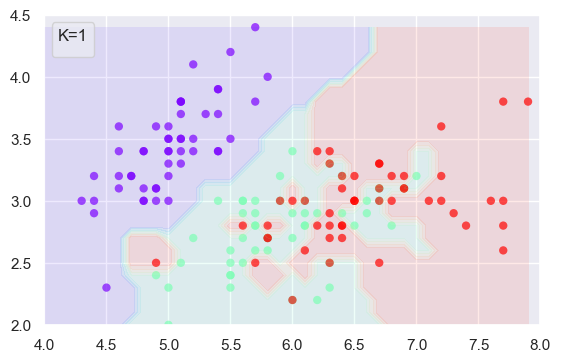

In [22]:
plot_iris(False)
plot_mesh(lambda x: k_nearest_classification(x, iris_x, iris_t, 1))
plt.legend([], loc="upper left", title="K=1")

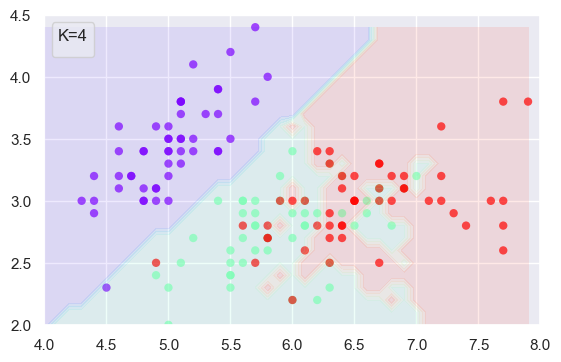

In [23]:
plot_iris(False)
plot_mesh(lambda x: k_nearest_classification(x, iris_x, iris_t, 4))
plt.legend([], loc="upper left", title="K=4")

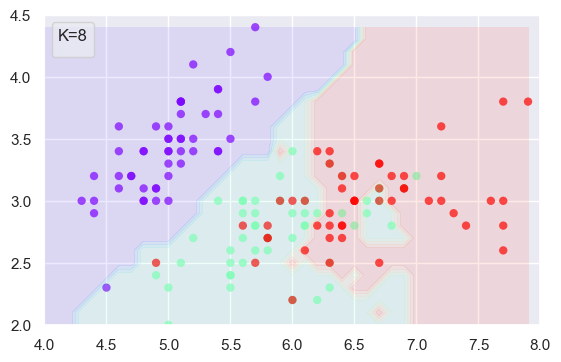

In [24]:
plot_iris(False)
plot_mesh(lambda x: k_nearest_classification(x, iris_x, iris_t, 8))
plt.legend([], loc="upper left", title="K=8")

## 4) K-Means clustering

Write a function `k_means_step(mus_0, data_x)` that performs a SINGLE ITERATION of the K-means algorithm:

- Assign each data point in `data_x` to the closest mean in `mus_0`.

- Compute the new cluster means as the average of the points assigned to each cluster.

- Return the updated means `mus` and the cluster assignments `classes`.

In [25]:
def k_means_step(mus_0, data_x):
    """Perform one iteration of the K-means algorithm (L8 slide 8).

    Parameters
    ----------
    mus_0 : array-like, shape (K, D)
        Current cluster means (one mean vector per row).
    data_x : array-like, shape (N, D)
        Data points.

    Returns
    -------
    mus : numpy array, shape (K, D)
        Updated cluster means after reassignment.
    classes : list of int, length N
        Cluster index (0 .. K-1) assigned to each data point.
    """
    rows = len(data_x)
    classes = np.zeros(rows, dtype=int)
    for i in range(rows):
        dist_min = np.inf
        index_mu_min = 0
        for j in range(len(mus_0)):
            dist_temp = np.linalg.norm(data_x[i]-mus_0[j])
            if (dist_temp < dist_min):
                dist_min = dist_temp
                index_mu_min = j
        classes[i] = index_mu_min
        
    K = len(mus_0)
    D = len(mus_0[0])
    mus = np.zeros((K, D))
    
    for k in range(K):
        cluster_points_temp = data_x[classes == k] # puntos asociados a la media "k". Guarda puntos donde se cumple la condición (True)
        if len(cluster_points_temp) > 0:
            mus[k] = np.mean(cluster_points_temp, axis=0)
        else:
            # Si no se le asignó ningún punto, conserva la media anterior
            mus[k] = mus_0[k]
    
    return mus, classes

Write a function distortion_measure(mus, classes, data_x) that computes the distortion (the K-means objective value):

    For each data point in data_x, find the mean in mus that it was assigned to (given by classes).

    Compute the squared distance between the point and its assigned mean.

    Sum these squared distances over all points.

The function should return this total sum, which is the distortion of the current clustering (see slide 8 of Lecture 8).

In [26]:
def distortion_measure(mus, classes, data_x):
    """Compute the K-means distortion objective J (L8 slide 8).

    Parameters
    ----------
    mus : array-like, shape (K, D)
        Cluster means.
    classes : list of int, length N
        Cluster assignment for each data point.
    data_x : array-like, shape (N, D)
        Data points.

    Returns
    -------
    float
        Total distortion J = sum over n of ||x_n - mu_{classes[n]}||^2.
    """
    classes = np.array(classes)
    K = len(mus)
    distortion = 0.0
    
    for k in range(K):
        # Seleccionamos todos los puntos pertenecientes al cluster k
        x_cluster = data_x[classes == k]
        
        if len(x_cluster) > 0:
            # Calculamos las distancias al cuadrado de todos esos puntos respecto a mus[k]
            # np.linalg.norm con axis=1 para calcular la norma de cada fila
            dists_sq = np.linalg.norm(x_cluster - mus[k], axis=1) ** 2
            distortion += np.sum(dists_sq)
        
    return float(distortion) 
    

Write a function optimize_k_means(mus_0, data_x) that runs the K-means algorithm until convergence:

    Start from the initial means mus_0.

    Repeatedly apply k_means_step to update cluster assignments and means.

    Stop when the assignments no longer change.

    Return the final means mus and assignments classes.

In [27]:
def optimize_k_means(mus_0, data_x):
    """Run K-means until cluster assignments converge.

    Parameters
    ----------
    mus_0 : array-like, shape (K, D)
        Initial cluster means.
    data_x : array-like, shape (N, D)
        Data points.

    Returns
    -------
    mus : numpy array, shape (K, D)
        Final cluster means after convergence.
    classes : list of int, length N
        Final cluster assignment for each data point.

    Hint: stop when classes does not change between two consecutive k_means_step calls.
    """
    max_iter = 300
    mu_current = mus_0
    classes_current = None
    
    for _ in range(max_iter):
        # 1. Ejecutar un paso de K-means
        mu_temp, classes_temp = k_means_step(mu_current, data_x)
        
        # 2. Verificar si la asignación de clases no cambió
        if classes_current is not None and np.array_equal(classes_current, classes_temp):
            break  # Ha convergido
            
        # 3. Actualizar variables para la siguiente iteración
        mu_current = mu_temp
        classes_current = classes_temp
        
    return mu_current, classes_current
    

Apply K-means on IRIS data

In [28]:
k = 3
mus_0 = iris_x[:k]                 # first k points as initial centers
mus, classes = optimize_k_means(mus_0, iris_x)

Plot the input IRIS data along with the final cluster centers 

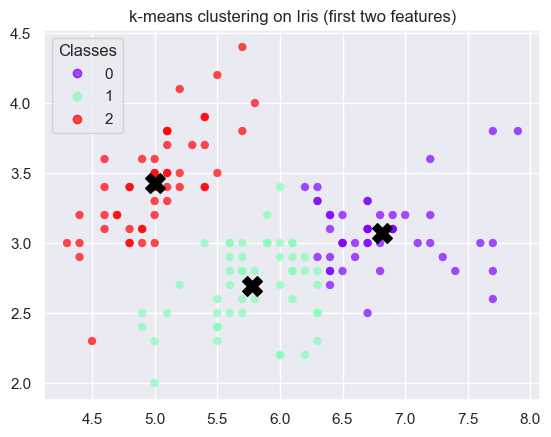

In [29]:
plt.figure()
plot_iris(legend=True, classes=classes)   # use k-means cluster assignments
plt.scatter(mus[:, 0], mus[:, 1], marker='X', s=200, c='black')  # mark centers
plt.title("k-means clustering on Iris (first two features)")
plt.show()

### Optional Exercise: Plot the progression of cluster means

Modify your K-means implementation so that after each iteration, you store the current means. Then, create a plot that shows how the cluster centers move step by step until convergence.

Hints:

Keep a list of means after each iteration.

Use scatter plots of the data points and plot the cluster centers (e.g. with X markers).

You may use different colors or arrows to show the trajectory of each cluster center.